In [61]:
import torch
from torch import nn
import matplotlib.pyplot as plt

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

print(torch.__version__ , torchvision.__version__)

2.5.1 0.20.1


In [63]:
#Training data
train_data = datasets.FashionMNIST(
    root = "data", #where to download data to?
    train = True,  #get training data
    download = True, #download data if it doesn't exist on folder
    transform = ToTensor(), # image come as PIL format, 
    target_transform = None
)
#testing data 
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor()
)

In [65]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [67]:
image.shape

torch.Size([1, 28, 28])

In [69]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [71]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

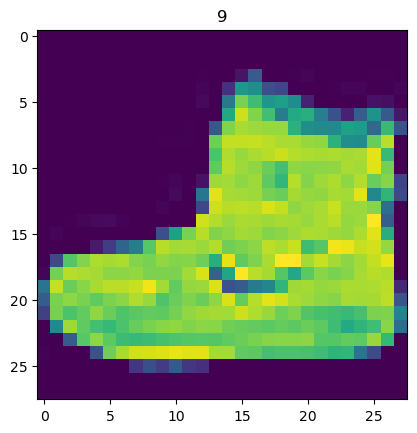

In [73]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

In [75]:
print(train_data)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [77]:
print(test_data)

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [79]:
print(train_data.data.shape)

torch.Size([60000, 28, 28])


In [81]:
print(test_data.data.shape)

torch.Size([10000, 28, 28])


In [83]:
print(train_data.targets.shape)
print(test_data.targets.shape)

torch.Size([60000])
torch.Size([10000])


Text(0.5, 1.0, 'Sandal')

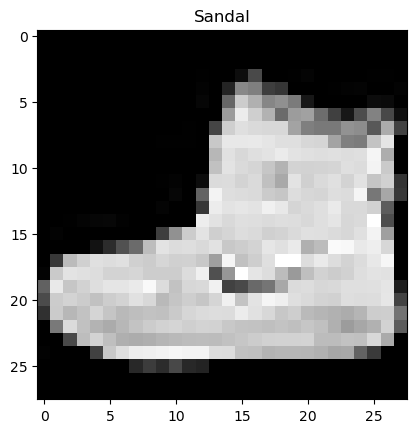

In [85]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])

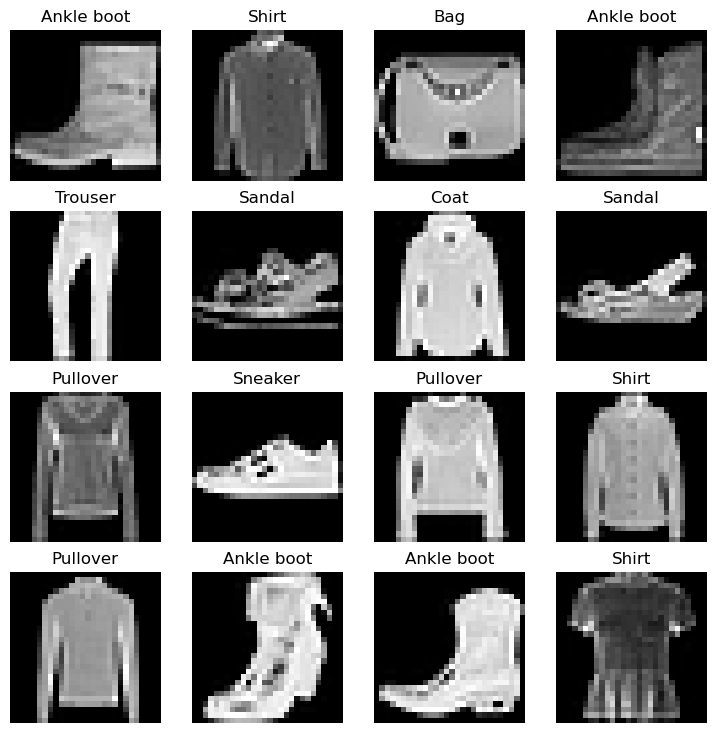

In [87]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows * cols +1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap = "gray")
    plt.title(class_names[label])
    plt.axis(False)

In [89]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_dataloader = DataLoader(train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)

test_dataloader = DataLoader(test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False)

print(f"Dataloader: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)}")
print(f"Length of test dataloader: {len(test_dataloader)}")

Dataloader: (<torch.utils.data.dataloader.DataLoader object at 0x00000208BAD5FEE0>, <torch.utils.data.dataloader.DataLoader object at 0x00000208BACD72E0>)
Length of train dataloader: 1875
Length of test dataloader: 313


In [91]:
313 * 32

10016

In [93]:
#checking inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(train_features_batch.shape, train_labels_batch.shape)

print(len(train_features_batch), len(train_labels_batch))

torch.Size([32, 1, 28, 28]) torch.Size([32])
32 32


Text(0.5, 1.0, 'Coat')

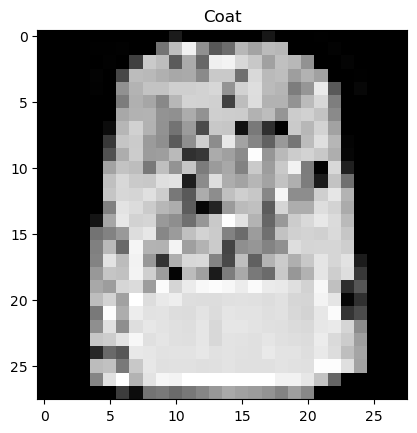

In [95]:
img, label = train_features_batch[4], train_labels_batch[4]
plt.imshow(img.squeeze(), cmap= "gray")
plt.title(class_names[label])


In [97]:
28 * 28

784

In [99]:
from torch import nn

#creating the flatten layer
flatten_model = nn.Flatten() # all nn modules function as a model (can do a forward pass)

#Get a single sample
x= train_features_batch[0] 

#flatten the sample
output = flatten_model(x) # perform forward pass 

print(f" Shape before flattening: {x.shape}") #[color_channel, height, weight]
print(f" shape after flattening: {output.shape}") #it is just a rearrangment of elements
#[color_channel, height * weight]->[1, 28 * 28]


 Shape before flattening: torch.Size([1, 28, 28])
 shape after flattening: torch.Size([1, 784])


In [101]:
#create a model
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units:int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, out_features= hidden_units),
            nn.Linear(in_features = hidden_units, out_features = output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

In [103]:
model_0 = FashionMNISTModelV0(input_shape = 784, hidden_units = 10, 
                             output_shape = len(class_names))

model_0



FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [105]:
#setup loss function and optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)


In [107]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [109]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device : torch.device= None):
    total_time = end - start 
    print(f" Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [111]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start = timer()
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}")
    train_loss = 0 

    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(f" Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
            
    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X)

            test_loss += loss_fn(test_pred, y)

            test_acc += accuracy_fn(y_true = y,
                                   y_pred = test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)
            
    print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

train_time_end = timer()
training_time_model_0 = print_train_time(start = train_time_start,
                                 end = train_time_end,
                                 device = str(next(model_0.parameters()).device))

  0%|                                                                                            | 0/3 [00:00<?, ?it/s]

Epoch : 0
 Looked at 0/60000 samples
 Looked at 12800/60000 samples
 Looked at 25600/60000 samples
 Looked at 38400/60000 samples
 Looked at 51200/60000 samples


 33%|████████████████████████████                                                        | 1/3 [00:19<00:38, 19.11s/it]

Train loss: 0.59322 | Test loss: 0.50451, Test acc: 82.34%

Epoch : 1
 Looked at 0/60000 samples
 Looked at 12800/60000 samples
 Looked at 25600/60000 samples
 Looked at 38400/60000 samples
 Looked at 51200/60000 samples


 67%|████████████████████████████████████████████████████████                            | 2/3 [00:43<00:22, 22.35s/it]

Train loss: 0.47777 | Test loss: 0.48460, Test acc: 82.98%

Epoch : 2
 Looked at 0/60000 samples
 Looked at 12800/60000 samples
 Looked at 25600/60000 samples
 Looked at 38400/60000 samples
 Looked at 51200/60000 samples


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [01:02<00:00, 20.88s/it]

Train loss: 0.45572 | Test loss: 0.47978, Test acc: 83.48%

 Train time on cpu: 62.657 seconds


In [113]:
def evaluate_model(model:torch.nn.Module,
                   data_loader: torch.utils.data.DataLoader,
                   loss_fn: torch.nn.Module,
                   accuracy_fn,
                  device: torch.device = device):

    loss,acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for X,y in data_loader:
            X,y= X.to(device),y.to(device)
            y_pred = model(X)

            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true = y,
                              y_pred = y_pred.argmax(dim=1))

        loss/= len(data_loader)
        acc/= len(data_loader)
        
    return {
        "Model Name": model.__class__.__name__,
        "Model loss": loss.item(),
        "Model accuracy": acc
    }               

In [115]:
model_0_results= evaluate_model(model=model_0,
                                data_loader = test_dataloader,
                                loss_fn = loss_fn,
                                accuracy_fn = accuracy_fn,
                               device= device)

model_0_results

{'Model Name': 'FashionMNISTModelV0',
 'Model loss': 0.4797831177711487,
 'Model accuracy': 83.47643769968052}

In [117]:
accuracy_fn

<function helper_functions.accuracy_fn(y_true, y_pred)>

In [119]:
#Building a better model with non-linearity

class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int , hidden_units : int , output_shape:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features = hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = output_shape),
            nn.ReLU()
        )
    def forward(self, x: torch.Tensor):
         return self.layer_stack(x)

In [121]:
model_1 = FashionMNISTModelV1(784,10,10)
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [123]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

In [125]:
#creating function for training and testing the model

def train_step(model : torch.nn.Module,
               data_loader : torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)


        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss +=loss
        train_acc += accuracy_fn(y_pred=y_pred.argmax(dim=1),
                                 y_true=y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss/=len(data_loader)
    train_acc/= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")



def test_step( model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, accuracy_fn,
               device: torch.device= device
              ):
    test_loss, test_acc = 0 , 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y =X.to(device), y.to(device)

            test_pred = model(X)
            test_loss+= loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true = y,
                                    y_pred = test_pred.argmax(dim=1))

        test_loss/=len(data_loader)
        test_acc/= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")
            

In [127]:
from timeit import default_timer as timer
train_time_start = timer()
epochs =3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n")
    train_step(model=model_1,
               data_loader = train_dataloader,
               loss_fn=loss_fn,
               optimizer = optimizer,
               accuracy_fn = accuracy_fn
    )
    test_step(model = model_1,
              data_loader = test_dataloader,
              loss_fn = loss_fn,
              accuracy_fn = accuracy_fn
             )
train_time_end= timer()
train_time_model_1 = print_train_time(start=train_time_start,
                             end=train_time_end,
                             device=device)

  0%|                                                                                            | 0/3 [00:00<?, ?it/s]

Epoch: 0

Train loss: 0.90989 | Train accuracy: 68.42%


 33%|████████████████████████████                                                        | 1/3 [00:18<00:36, 18.19s/it]

Test loss: 0.73556 | Test accuracy: 74.03%

Epoch: 1

Train loss: 0.68545 | Train accuracy: 75.03%


 67%|████████████████████████████████████████████████████████                            | 2/3 [00:34<00:17, 17.01s/it]

Test loss: 0.70139 | Test accuracy: 75.13%

Epoch: 2

Train loss: 0.65636 | Train accuracy: 75.78%


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:57<00:00, 19.09s/it]

Test loss: 0.67676 | Test accuracy: 74.97%

 Train time on cpu: 57.269 seconds


In [129]:
model_1_results = evaluate_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'Model Name': 'FashionMNISTModelV1',
 'Model loss': 0.6767607927322388,
 'Model accuracy': 74.97004792332268}

In [131]:
model_0_results= evaluate_model(model=model_0,
                                data_loader = test_dataloader,
                                loss_fn = loss_fn,
                                accuracy_fn = accuracy_fn,
                               device= device)

model_0_results

{'Model Name': 'FashionMNISTModelV0',
 'Model loss': 0.4797831177711487,
 'Model accuracy': 83.47643769968052}

In [133]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape:int):
       super().__init__()
       self.block_1 = nn.Sequential(
           nn.Conv2d(in_channels = input_shape,
                     out_channels = hidden_units,
                     kernel_size = 3,
                     stride =1,
                     padding=1),
           nn.ReLU(),
           nn.Conv2d(in_channels =hidden_units,
                     out_channels =hidden_units,
                    kernel_size= 3,
                    stride=1,
                    padding=1),
           nn.ReLU(),
           nn.MaxPool2d(kernel_size=2,
                        stride =2)
       )
       self.block_2 = nn.Sequential(
           nn.Conv2d(hidden_units, hidden_units,3,padding = 1),
           nn.ReLU(),
           nn.Conv2d(hidden_units, hidden_units,3, padding = 1),
           nn.ReLU(),
           nn.MaxPool2d(2)
       )
       self.classifier= nn.Sequential(
           nn.Flatten(),
           nn.Linear(in_features = hidden_units*7*7,
                     out_features = output_shape)
       )
    def forward(self, x: torch.Tensor):
       x = self.block_1(x)
       # print(x.shape)
       x = self.block_2(x)
       # print(x.shape)
       x = self.classifier(x)
       # print(x.shape)
       return x



In [135]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [137]:
torch.manual_seed(42)

#create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 1 , 28, 28))
test_image = images[0]

print(f"sample image shape:{test_image.shape}")
print(f"image batch shape:{images.shape}")
print(f"single image values:{test_image}")


sample image shape:torch.Size([1, 28, 28])
image batch shape:torch.Size([32, 1, 28, 28])
single image values:tensor([[[ 1.9269e+00,  1.4873e+00,  9.0072e-01, -2.1055e+00,  6.7842e-01,
          -1.2345e+00, -4.3067e-02, -1.6047e+00, -7.5214e-01,  1.6487e+00,
          -3.9248e-01, -1.4036e+00, -7.2788e-01, -5.5943e-01, -7.6884e-01,
           7.6245e-01,  1.6423e+00, -1.5960e-01, -4.9740e-01,  4.3959e-01,
          -7.5813e-01,  1.0783e+00,  8.0080e-01,  1.6806e+00,  1.2791e+00,
           1.2964e+00,  6.1047e-01,  1.3347e+00],
         [-2.3162e-01,  4.1759e-02, -2.5158e-01,  8.5986e-01, -1.3847e+00,
          -8.7124e-01, -2.2337e-01,  1.7174e+00,  3.1888e-01, -4.2452e-01,
           3.0572e-01, -7.7459e-01, -1.5576e+00,  9.9564e-01, -8.7979e-01,
          -6.0114e-01, -1.2742e+00,  2.1228e+00, -1.2347e+00, -4.8791e-01,
          -9.1382e-01, -6.5814e-01,  7.8024e-02,  5.2581e-01, -4.8799e-01,
           1.1914e+00, -8.1401e-01, -7.3599e-01],
         [-1.4032e+00,  3.6004e-02, -6.34

In [139]:
#in_channels takes number of color channels
#out_channels gives number of filters
conv_layer = nn.Conv2d(in_channels = 1,
                       out_channels = 10,
                      kernel_size = 3,
                      stride =1,
                      padding=0)
conv_layer(test_image)

tensor([[[-0.2861,  0.0360, -1.2057,  ..., -0.1070, -0.6212, -0.3955],
         [-0.5067, -0.6134, -0.4557,  ..., -0.8525, -0.5058, -0.6742],
         [ 0.5553, -0.4960, -0.0805,  ..., -0.2120, -0.4326, -0.1943],
         ...,
         [-0.3023, -1.6971, -0.5894,  ..., -1.3007, -0.0394, -0.6314],
         [-1.0088, -0.2744, -0.1884,  ...,  0.0815, -0.2720,  0.4962],
         [-0.8905, -0.8848, -0.8191,  ..., -0.8776, -0.6440, -0.0434]],

        [[-1.0893,  0.6643, -1.4547,  ..., -0.4452, -1.5614, -0.4868],
         [-0.3226, -0.3927,  0.2965,  ..., -0.7980, -0.1782, -0.0991],
         [ 0.2044, -0.4384,  0.4390,  ...,  0.2687, -0.3754,  0.6988],
         ...,
         [ 1.1178, -0.9539,  0.1886,  ..., -0.0287,  0.4071, -0.4764],
         [-2.0638,  1.5483,  0.1014,  ..., -0.2129, -0.7188,  0.4678],
         [-1.1512,  0.5734, -1.1250,  ..., -1.3873, -0.8680, -0.1561]],

        [[ 0.7191,  0.5880,  0.2396,  ...,  0.4382,  0.6450, -0.0773],
         [ 0.9310,  0.6516,  0.8961,  ...,  0

In [141]:
test_image.unsqueeze(dim=0).shape

torch.Size([1, 1, 28, 28])

In [143]:
conv_layer(test_image.unsqueeze(dim=0)).shape
# Output = (Input - Kernel + 1)
#torch.Size([1, 10, 26, 26]) is output size, if produce 10 filters of each
# size 26 X 26 , apply above formula 28-3+1 = 26

torch.Size([1, 10, 26, 26])

In [145]:
print(f" Test image original shpae: {test_image.shape}")
print(f" Test image with unsqueeze dimension: {test_image.unsqueeze(dim=0).shape}")

#create a sample nn.MaxPool2d() layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer and max_pool_layer(): \n {test_image_through_conv_and_max_pool.shape}")

 Test image original shpae: torch.Size([1, 28, 28])
 Test image with unsqueeze dimension: torch.Size([1, 1, 28, 28])
Shape after going through conv_layer(): torch.Size([1, 10, 26, 26])
Shape after going through conv_layer and max_pool_layer(): 
 torch.Size([1, 10, 13, 13])


In [147]:
# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), 
                             lr=0.1)

In [149]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model 
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model_2, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|                                                                                            | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.30494 | Train accuracy: 88.95%


 33%|████████████████████████████                                                        | 1/3 [00:59<01:59, 59.99s/it]

Test loss: 0.32468 | Test accuracy: 88.23%

Epoch: 1
---------
Train loss: 0.29208 | Train accuracy: 89.38%


 67%|████████████████████████████████████████████████████████                            | 2/3 [02:06<01:03, 63.93s/it]

Test loss: 0.31881 | Test accuracy: 88.20%

Epoch: 2
---------
Train loss: 0.28375 | Train accuracy: 89.71%


100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [03:09<00:00, 63.26s/it]

Test loss: 0.31686 | Test accuracy: 88.60%

 Train time on cpu: 189.787 seconds


In [150]:
# Get model_2 results 
model_2_results = evaluate_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

{'Model Name': 'FashionMNISTModelV2',
 'Model loss': 0.3168611526489258,
 'Model accuracy': 88.59824281150159}

In [151]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,Model Name,Model loss,Model accuracy
0,FashionMNISTModelV0,0.479783,83.476438
1,FashionMNISTModelV1,0.676761,74.970048
2,FashionMNISTModelV2,0.316861,88.598243


In [152]:
compare_results["training_time"] = [train_time_model_0,
                                    train_time_model_1,
                                    train_time_model_2]
compare_results

NameError: name 'train_time_model_0' is not defined

In [ ]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");